In [173]:
%pip install pandas numpy scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [174]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


### Import library

In [175]:

import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout


# Project paths: force all files to stay inside Senior_Project_Text_Mining
BASE_DIR = Path.cwd()

if BASE_DIR.name != "Senior_Project_Text_Mining":
    possible_dir = BASE_DIR / "Senior_Project_Text_Mining"
    if possible_dir.exists():
        BASE_DIR = possible_dir
    else:
        raise FileNotFoundError(
            "Please open or run this notebook from the Senior_Project_Text_Mining folder."
        )

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR.resolve())
print("RAW_DIR:", RAW_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())


BASE_DIR: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining
RAW_DIR: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining\data\raw
PROCESSED_DIR: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining\data\processed


### Load Dataset

In [ ]:
file_path = RAW_DIR / "all_emotions-2.csv"
df = pd.read_csv(file_path)

print("Loaded from:", file_path.resolve())
print("Dataset shape:", df.shape)
df.head()


Loaded from: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining\data\raw\All_emotions.csv
Dataset shape: (7261, 3)


,speaker,utterance,emotion
0,patient,I can feel the cold water on my teeth.,neutral
1,dentist,It's important to keep the area clean.,neutral
2,patient,I try to brush twice a day like you said.,neutral
3,dentist,You might feel a bit of pressure.,neutral
4,patient,Should I open wider?,neutral


### Select Patient Utterances

In [177]:
df.columns = df.columns.str.strip().str.lower()

df = df[df["speaker"].str.lower() == "patient"].copy()

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (3636, 3)


,speaker,utterance,emotion
0,patient,I can feel the cold water on my teeth.,neutral
2,patient,I try to brush twice a day like you said.,neutral
4,patient,Should I open wider?,neutral
6,patient,I am not paying for a mistake you made.,angry
8,patient,I can feel the cold water on my teeth.,neutral


### Clean Text

In [178]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["utterance"].apply(clean_text)

df = df[df["clean_text"] != ""].copy()

df.head()

,speaker,utterance,emotion,clean_text
0,patient,I can feel the cold water on my teeth.,neutral,i can feel the cold water on my teeth
2,patient,I try to brush twice a day like you said.,neutral,i try to brush twice a day like you said
4,patient,Should I open wider?,neutral,should i open wider
6,patient,I am not paying for a mistake you made.,angry,i am not paying for a mistake you made
8,patient,I can feel the cold water on my teeth.,neutral,i can feel the cold water on my teeth


### Prepare Input Data

In [179]:
df = df[["clean_text", "emotion"]].dropna().copy()
df.columns = ["text", "label"]


neutral_df = df[df["label"] == "neutral"].copy()
other_df = df[df["label"] != "neutral"].copy()

neutral_df = neutral_df.sample(n=500, random_state=42)

df = pd.concat([neutral_df, other_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Prepared dataset shape:", df.shape)
print("\nLabel distribution after limiting neutral to 300:")
print(df["label"].value_counts())

df.head()

Prepared dataset shape: (1280, 2)

Label distribution after limiting neutral to 300:
label
neutral    500
disgust    247
fear       195
angry      156
sad         98
happy       84
Name: count, dtype: int64


,text,label
0,i got teary one night because i felt down beca...,sad
1,understood the smell when i walked in here tod...,disgust
2,there's so much of it three passes of that col...,disgust
3,the smell coming off as it removes the plaque ...,disgust
4,there's hardened bacteria sitting below my gum...,disgust


### Check Label Distribution

In [180]:
print(df["label"].value_counts())

label
neutral    500
disgust    247
fear       195
angry      156
sad         98
happy       84
Name: count, dtype: int64


### Save Cleaned Data

In [181]:
df.to_csv(PROCESSED_DIR / "cleaned_emotions_dl.csv", index=False)

print("Cleaned DL dataset saved successfully")
print("Saved to:", (PROCESSED_DIR / "cleaned_emotions_dl.csv").resolve())


Cleaned DL dataset saved successfully
Saved to: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining\data\processed\cleaned_emotions_dl.csv


### Split Dataset

In [182]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (896, 2)
Validation shape: (192, 2)
Test shape: (192, 2)


### Oversampling on train set only

In [183]:
# max_count = train_df["label"].value_counts().max()

# balanced_train_parts = []

# for label_name in train_df["label"].unique():
#     class_subset_df = train_df[train_df["label"] == label_name]

#     class_subset_upsampled = resample(
#         class_subset_df,
#         replace=True,
#         n_samples=max_count,
#         random_state=42
#     )

#     balanced_train_parts.append(class_subset_upsampled)

# balanced_train_df = pd.concat(balanced_train_parts)
# balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# print("Train label distribution AFTER oversampling:")
# print(balanced_train_df["label"].value_counts())
# print("Balanced train shape:", balanced_train_df.shape)

### Tokenization

In [184]:
max_vocab_size = 10000

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("Sample word index:", list(word_index.items())[:10])

Vocabulary size: 1264
Sample word index: [('<OOV>', 1), ('i', 2), ('the', 3), ('my', 4), ('it', 5), ('to', 6), ('and', 7), ('that', 8), ('this', 9), ('is', 10)]


### Convert Text to Sequences

In [185]:
X_train_seq = tokenizer.texts_to_sequences(train_df["text"])
X_val_seq = tokenizer.texts_to_sequences(val_df["text"])
X_test_seq = tokenizer.texts_to_sequences(test_df["text"])

#print("Sample text:", balanced_train_df["text"].iloc[0])
print("Sample sequence:", X_train_seq[0])

Sample sequence: [28, 42, 43, 3, 216, 38]


### Pad Sequences

In [186]:
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Maximum sequence length:", max(sequence_lengths))
print("Average sequence length:", np.mean(sequence_lengths))
print("95th percentile length:", np.percentile(sequence_lengths, 95))

max_sequence_length = int(np.percentile(sequence_lengths, 95))
print("Chosen max sequence length:", max_sequence_length)

Maximum sequence length: 27
Average sequence length: 10.068080357142858
95th percentile length: 19.0
Chosen max sequence length: 19


In [187]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (896, 19)
X_val_pad shape: (192, 19)
X_test_pad shape: (192, 19)


### Encode Labels

In [188]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
y_test = label_encoder.transform(test_df["label"])

print("Classes:", label_encoder.classes_)
print("Sample encoded labels:", y_train[:10])

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Sample encoded labels: [4 2 1 1 4 1 4 1 1 2]


### One-Hot Encode Labels

In [189]:
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_cat shape: (896, 6)
y_val_cat shape: (192, 6)
y_test_cat shape: (192, 6)


### Compute class weights !

In [190]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)
print("Label classes:", label_encoder.classes_)

Class weights: {0: np.float64(1.3700305810397553), 1: np.float64(0.8631984585741811), 2: np.float64(1.0980392156862746), 3: np.float64(2.531073446327684), 4: np.float64(0.4266666666666667), 5: np.float64(2.1642512077294684)}
Label classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


### Save Processed Data

In [191]:
np.save(PROCESSED_DIR / "X_train_pad.npy", X_train_pad)
np.save(PROCESSED_DIR / "X_val_pad.npy", X_val_pad)
np.save(PROCESSED_DIR / "X_test_pad.npy", X_test_pad)

np.save(PROCESSED_DIR / "y_train.npy", y_train)
np.save(PROCESSED_DIR / "y_val.npy", y_val)
np.save(PROCESSED_DIR / "y_test.npy", y_test)

np.save(PROCESSED_DIR / "y_train_cat.npy", y_train_cat)
np.save(PROCESSED_DIR / "y_val_cat.npy", y_val_cat)
np.save(PROCESSED_DIR / "y_test_cat.npy", y_test_cat)

print("Processed arrays saved successfully")


Processed arrays saved successfully


### Save Tokenizer and Label Mapping

In [192]:
with open(PROCESSED_DIR / "word_index.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.word_index, f, ensure_ascii=False, indent=2)

label_mapping = {
    label: int(index)
    for index, label in enumerate(label_encoder.classes_)
}

with open(PROCESSED_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

print("Tokenizer word index and label mapping saved successfully")
print("Label mapping:", label_mapping)


Tokenizer word index and label mapping saved successfully
Label mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5}


### Final Summary

In [193]:
print("Deep learning preprocessing completed successfully")
print("Final training input shape:", X_train_pad.shape)
print("Final validation input shape:", X_val_pad.shape)
print("Final test input shape:", X_test_pad.shape)
print("Number of classes:", num_classes)
print("Vocabulary size:", len(tokenizer.word_index))
print("Max sequence length:", max_sequence_length)

print("\nSaved files in processed folder:")
for file in sorted(PROCESSED_DIR.iterdir()):
    print("-", file.name)


Deep learning preprocessing completed successfully
Final training input shape: (896, 19)
Final validation input shape: (192, 19)
Final test input shape: (192, 19)
Number of classes: 6
Vocabulary size: 1264
Max sequence length: 19

Saved files in processed folder:
- cleaned_emotions_dl.csv
- cleaned_emotions_patient.csv
- label_mapping.json
- patient_test_tfidf.csv
- patient_train_tfidf_smote.csv
- tfidf_features_patient.csv
- word_index.json
- X_test_pad.npy
- X_train_pad.npy
- X_val_pad.npy
- y_test.npy
- y_test_cat.npy
- y_train.npy
- y_train_cat.npy
- y_val.npy
- y_val_cat.npy


### Build model & Embedding แปลงคำเป็น vector

In [194]:
vocab_size = min(10000, len(word_index) + 1)
max_len = max_sequence_length

model = Sequential()

# Embedding
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# BiLSTM
model.add(Bidirectional(LSTM(64)))

# Regularization
model.add(Dropout(0.5))

# Hidden layer เพิ่มเข้ามา
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

model.summary()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### compile โมเดล

In [195]:
from tensorflow.keras.optimizers import Adam 

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

### train โมเดล

In [196]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2422 - loss: 1.7279 - val_accuracy: 0.3385 - val_loss: 1.5410 - learning_rate: 0.0010
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4531 - loss: 1.2532 - val_accuracy: 0.6615 - val_loss: 0.9833 - learning_rate: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6830 - loss: 0.5907 - val_accuracy: 0.7604 - val_loss: 0.6298 - learning_rate: 0.0010
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7824 - loss: 0.3311 - val_accuracy: 0.7760 - val_loss: 0.5333 - learning_rate: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8281 - loss: 0.2554 - val_accuracy: 0.8073 - val_loss: 0.4809 - learning_rate: 0.0010
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8929 - loss: 0.1782 - val_accuracy: 0.7812 - val_loss: 0.5725 - learning_rate: 0.0010
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9297 - loss: 0.1240 - val_accuracy:

In [197]:
loss, acc = model.evaluate(X_test_pad, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8594 - loss: 0.3736  
Test Loss: 0.3735584318637848
Test Accuracy: 0.859375


In [198]:
# Save trained model
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.save(MODEL_DIR / "bilstm_model.keras")

print("Model saved to:", (MODEL_DIR / "bilstm_model.keras").resolve())

Model saved to: C:\Users\Admin\Desktop\Senior-project\phase-2\Senior_Project_Text_Mining\models\bilstm_model.keras


In [199]:
import numpy as np

# predict
y_pred_prob = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

label_names = label_encoder.classes_

# Classification report
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=label_names
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        24
     disgust       0.92      0.92      0.92        37
        fear       0.60      0.72      0.66        29
       happy       1.00      1.00      1.00        13
     neutral       0.87      0.79      0.83        75
         sad       0.93      1.00      0.97        14

    accuracy                           0.86       192
   macro avg       0.89      0.90      0.89       192
weighted avg       0.87      0.86      0.86       192



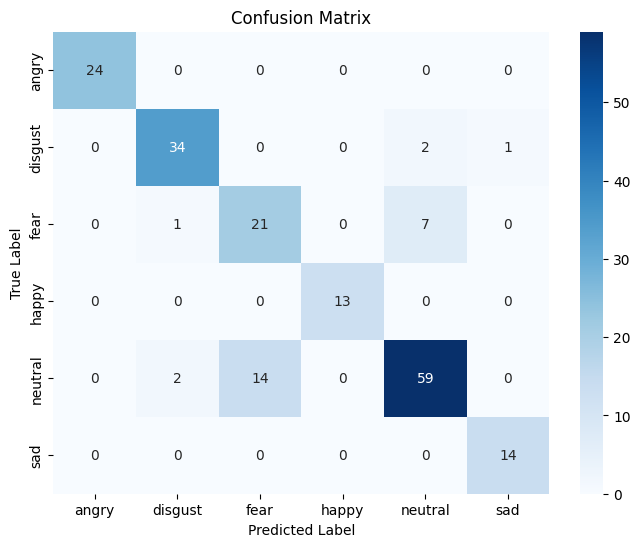

In [200]:
# =========================
# 28) Confusion matrix
# =========================
from matplotlib import pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()